# Azərbaycan üzrə beynəlxalq və daxili turizm paket satışları

## Layihə icmalı

Bu layihə Azərbaycanda turizm paket satışlarının zamanla necə dəyişdiyini araşdırır və daxili və beynəlxalq paketləri müqayisə etməyə yönəlib. Rəsmi açıq məlumatlardan istifadə edərək analiz uzunmüddətli meylləri, COVID-19 pandemiyası kimi əsas hadisələrin təsirini və turizm bazarında mümkün gələcək inkişafları müəyyən edir.

Məlumatlar **Digital Azerbaijan** saytından götürülüb.

## Biznes sualları

1. Daxili və beynəlxalq turizm paket satışları zamanla necə dəyişib?
2. Hangi illər ən güclü artımı və ya azalmayı göstərib?
3. COVID-19 pandemiyası turizm paket satışlarına necə təsir edib?
4. Pandemiyadan sonra hansı turizm növü daha tez bərpa olub?
5. Növbəti beş il üçün satış meylləri necə gözlənilir?

## Məlumatların toplanması
Bu hissədə dataset birbaşa Azərbaycan Açıq Məlumat API-sindən idxal edilir. Məlumatlar əlavə emal və analiz üçün pandas DataFrame-ə yüklənir.

In [154]:
import chardet
import requests
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import numpy as np
from io import StringIO
import urllib3
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
url = "https://admin.opendata.az/api/3/action/package_show?id=value-of-tourism-envelopes-sold"

data = requests.get(url).json()

resources = data["result"]["resources"]
csv_url = resources[0]["url"]

# CSV-ni təhlükəsiz yükləmək
response = requests.get(csv_url, verify=False)
csv_data = StringIO(response.text)

result = chardet.detect(response.content)
encoding = result['encoding']

print("Detected encoding:", encoding)

df = pd.read_csv(StringIO(response.content.decode(encoding)))
print(df.head())

Detected encoding: utf-8
   Year  Unnamed: 1  Satılmış turizm zərflərinin dəyəri (min manat)  \
0  2024         NaN                                        128675.6   
1  2023         NaN                                         26915.5   
2  2022         NaN                                         15915.2   
3  2021         NaN                                          5374.0   
4  2020         NaN                                          4988.4   

   Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)  \
0                                             2404.7                                                            
1                                             2098.0                                                            
2                                              803.3                                                            
3                                              467.1                                            

## İlkin dataset yoxlanışı
Məlumatları yüklədikdən sonra ilk addım onun quruluşunu yoxlamaqdır. Bu, aşağıdakıları əhatə edir:

* Sətir və sütun sayı
* Məlumat tipləri
* İtkin dəyərlər
* Ümumi statistik xülasə

Bu addım təmizləmə və modelləşdirmə öncəsi potensial problemləri müəyyən etməyə kömək edir.

In [149]:
df.head()

,Year,Satılmış turizm zərflərinin dəyəri (min manat),Domestic,International,Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat),Covid,Year_centered
0,2024,128675.6,2.4047,117.1581,9112.8,18023.4,110652.2,0,11.5
1,2023,26915.5,2.0980,19.8898,4927.7,4766.4,22149.1,0,10.5
2,2022,15915.2,0.8033,11.2066,3905.3,2224.2,13691.0,1,9.5
3,2021,5374.0,0.4671,4.6391,267.8,828.0,4546.0,1,8.5
4,2020,4988.4,0.0158,4.1624,810.2,716.8,4271.6,1,7.5


In [150]:
df.shape ## Verilənlərin ölçüsünü göstərir.

(24, 9)

In [128]:
df.info() ## DataFrame haqqında əsas məlumatları göstərir.

<class 'pandas.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 8 columns):
 #   Column                                                                                                                             Non-Null Count  Dtype  
---  ------                                                                                                                             --------------  -----  
 0   Year                                                                                                                               24 non-null     int64  
 1   Unnamed: 1                                                                                                                         0 non-null      float64
 2   Satılmış turizm zərflərinin dəyəri (min manat)                                                                                     24 non-null     float64
 3   Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min mana

In [129]:
df.describe() ## Rəqəmsal sütunların statistik xülasəsini göstərir.

,Year,Unnamed: 1,Satılmış turizm zərflərinin dəyəri (min manat),Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat),Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat)
count,24.000000,0.0,24.000000,24.000000,24.000000,24.000000,24.000000,24.000000
mean,2012.500000,NaN,28433.270833,2221.670833,22344.258333,3867.345833,7711.312500,20697.016667
std,7.071068,NaN,30581.126369,2076.037412,25710.571454,4981.944825,7956.340163,24039.628367
min,2001.000000,NaN,198.600000,0.000000,198.600000,0.000000,0.000000,0.000000
25%,2006.750000,NaN,5277.600000,719.250000,4519.925000,265.500000,800.200000,4477.400000
50%,2012.500000,NaN,20881.950000,1983.450000,15894.950000,2142.500000,3798.000000,13795.150000
75%,2018.250000,NaN,41242.975000,2859.850000,34487.050000,4766.000000,12752.450000,27555.625000
max,2024.000000,NaN,128675.600000,7071.800000,117158.100000,20289.000000,27204.200000,110652.200000


In [130]:
df.isna().sum() ## Hər sütunda çatışmayan (boş) dəyərləri yoxla

Year                                                                                                                                  0
Unnamed: 1                                                                                                                           24
Satılmış turizm zərflərinin dəyəri (min manat)                                                                                        0
Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)                            0
Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)                           0
Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat)     0
Qrup halında satılmış turizm zərflərinin dəyəri (min manat)                                                                           0
Fərdi halda satılmış turizm zərflərinin dəyəri (

## Sütun adlarının dəyişdirilməsi
Orijinal azərbaycan dilində sütun adları qısa ingilis adlarına çevrilir. Həmçinin, adlar qısaldılmalıdır.

In [131]:
df.rename(columns={
    "Ölkə daxilində səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)": "Domestic",
    "Ölkədən kənarda səyahət etmək üçün Azərbaycan vətəndaşlarına satılmış turizm zərflərinin dəyəri (min manat)": "International"
}, inplace=True)

# Rəqəmə çevir (təhlükəsizlik)
df["Domestic"] = pd.to_numeric(df["Domestic"], errors="coerce") / 1000
df["International"] = pd.to_numeric(df["International"], errors="coerce") / 1000

## Məlumatların təmizlənməsi
Dataset itkin dəyərlərdən təmizlənir.

In [132]:
df.drop(columns=["Unnamed: 1"], errors="ignore", inplace=True) ## Boş sütunu sil

In [151]:
df.head()

,Year,Satılmış turizm zərflərinin dəyəri (min manat),Domestic,International,Azərbaycan ərazisinə səyahət etmək üçün əcnəbilər və vətəndaşlığı olmayan şəxslərə satılmış turizm zərflərinin dəyəri (min manat),Qrup halında satılmış turizm zərflərinin dəyəri (min manat),Fərdi halda satılmış turizm zərflərinin dəyəri (min manat),Covid,Year_centered
0,2024,128675.6,2.4047,117.1581,9112.8,18023.4,110652.2,0,11.5
1,2023,26915.5,2.0980,19.8898,4927.7,4766.4,22149.1,0,10.5
2,2022,15915.2,0.8033,11.2066,3905.3,2224.2,13691.0,1,9.5
3,2021,5374.0,0.4671,4.6391,267.8,828.0,4546.0,1,8.5
4,2020,4988.4,0.0158,4.1624,810.2,716.8,4271.6,1,7.5


## Kəşfiyyat Məlumat Analizi
Bu bölmə daxili və beynəlxalq turizm paket satışlarının tarixi inkişafını müqayisə edir.

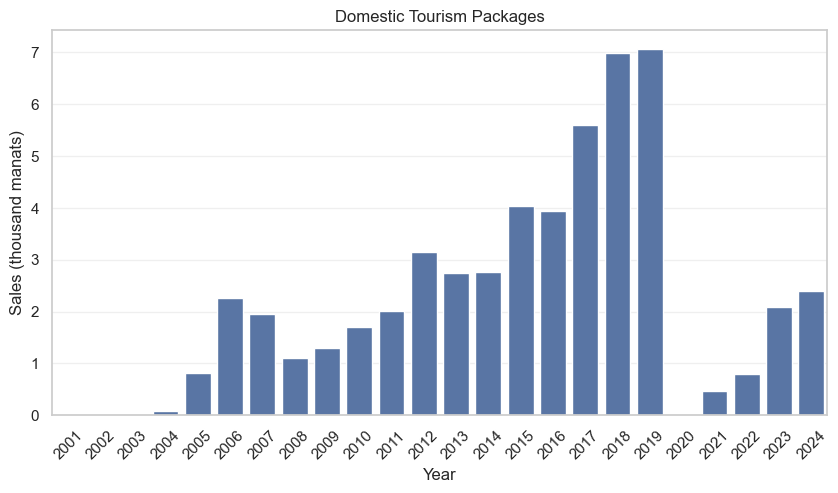

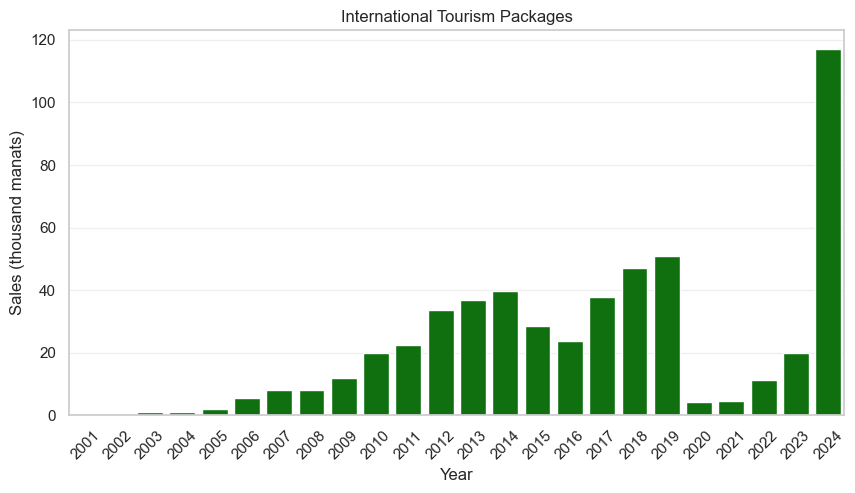

In [134]:
import matplotlib.pyplot as plt
import seaborn as sns

# Domestic
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Year", y="Domestic")
plt.title("Domestic Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

# International
plt.figure(figsize=(10,5))
sns.barplot(data=df, x="Year", y="International", color="green")
plt.title("International Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

Paket tur satışları 2004-cü ildən (daxili) və 2003-cü ildən (beynəlxalq) qeyri-xətti olaraq artmağa başladı, lakin 2020-ci ildə kəskin şəkildə azaldı. Daxili bazarda beynəlxalq satışlar 2024-cü ildə kəskin artdı.

## COVID-19 təsiri
COVID-19 dövrü turizm paket satışlarına təsirini anlamaq üçün ayrıca təhlil edilir.

In [135]:
# Covid göstəricisi
df["Covid"] = df["Year"].isin([2020, 2021, 2022]).astype(int)

# İli mərkəzləşdir
year_mean = df["Year"].mean()
df["Year_centered"] = df["Year"] - year_mean
features = ["Year_centered", "Covid"]

Covid xüsusiyyəti: modellə bildirir ki, 2020–2022 illəri qeyri-adi illər olub, buna görə də satıcı nümunələrini normal saymır.

Year_centered: zaman dəyişənini model üçün daha asan öyrənilən edir (daha yaxşı sabitlik və şərh).

In [ ]:
# -------------------------
# BEYNƏLXALQ
# -------------------------
df_filtered_int = df[df["Year"] != 2024].copy()

x_int = df_filtered_int[features]
y_int = df_filtered_int["International"]

# -------------------------
# DAXILI
# -------------------------
df_dom_filtered = df[df["Year"] >= 2010]

x_dom = df_dom_filtered[features]
y_dom = df_dom_filtered["Domestic"]

# -------------------------
# MODELLƏRİ ÖYRƏT
# -------------------------
lr_int = LinearRegression()
lr_dom = LinearRegression()

lr_int.fit(x_int, y_int)
lr_dom.fit(x_dom, y_dom)

dt_int = DecisionTreeRegressor(max_depth=5, random_state=42)
dt_dom = DecisionTreeRegressor(max_depth=5, random_state=42)

dt_int.fit(x_int, y_int)
dt_dom.fit(x_dom, y_dom)

rf_int = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)
rf_dom = RandomForestRegressor(n_estimators=200, max_depth=5, random_state=42)

rf_int.fit(x_int, y_int)
rf_dom.fit(x_dom, y_dom)

# -------------------------
# BÖLÜNMƏ (VACİB DƏYİŞİKLİK BURADA)
# -------------------------

# BEYNƏLXALQ
train_mask_int = df_filtered_int["Year"] < 2022
test_mask_int  = df_filtered_int["Year"] >= 2022

x_train_int = x_int[train_mask_int]
x_test_int  = x_int[test_mask_int]

y_train_int = y_int[train_mask_int]
y_test_int  = y_int[test_mask_int]

# DAXILI (BURADA DA FILTRLƏNMƏDƏN İSTİFADƏ EDİN)
train_mask_dom = df_dom_filtered["Year"] < 2022
test_mask_dom  = df_dom_filtered["Year"] >= 2022

x_train_dom = x_dom[train_mask_dom]
x_test_dom  = x_dom[test_mask_dom]

y_train_dom = y_dom[train_mask_dom]
y_test_dom  = y_dom[test_mask_dom]

Bu kod Beynəlxalq və Daxili satışlar üçün ayrı proqnozlaşdırma modellərini qurur və qiymətləndirir.

* Məlumatların filtrlenməsi
  * Beynəlxalq: 2024-cü il istisna edilir, çünki çıxıntı kimi davranır
  * Daxili: 2010-cu ildən başlayaraq istifadə olunur
* Xüsusiyyət və hədəf təyini
  * x_* → giriş xüsusiyyətləri (Year_centered, Covid)
  * y_* → hədəf satışlar (Beynəlxalq və ya Daxili)
* Model öyrənməsi
Hər seqment üçün üç model öyrədilir:
  * Xətti Reqressiya → ümumi meyli tutur
  * Qərar Ağacı → qeyri-xətti nümunələri tutur
  * Random Forest → bir neçə ağac istifadə edərək dəqiqliyi artırır
* Təlim/test paylaşdırılması (zaman əsaslı)
  * Train: 2022-dən əvvəlki illər
  * Test: 2022 və sonrakılar
(xronoloji ardıcıllığı saxlayır → proqnozlaşdırma üçün vacibdir)

## Artım sürəti analizi
Artım tempi sürətli artım və ya azalma dövrlərini müəyyən etmək üçün hesablanır.

/var/folders/cf/zcynrpr90_dcthvft6l4jrmr0000gn/T/ipykernel_21700/4026395688.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


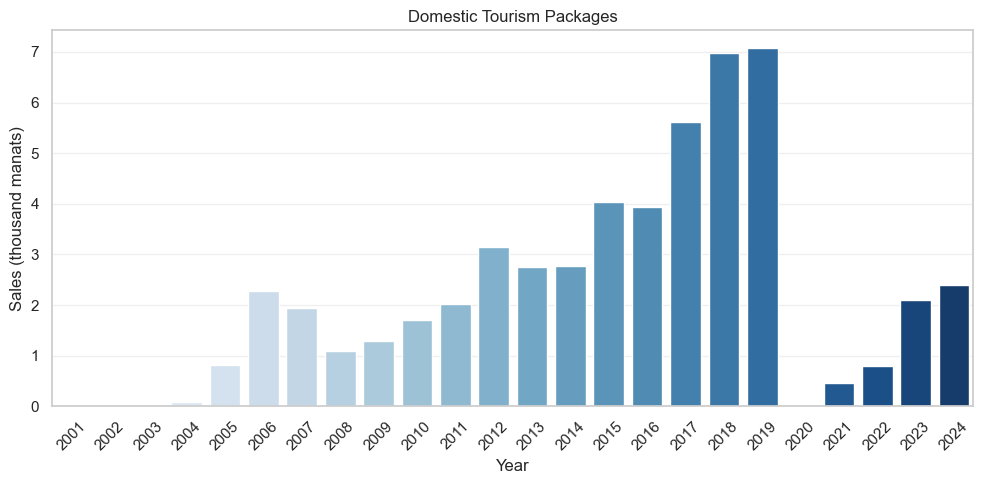

/var/folders/cf/zcynrpr90_dcthvft6l4jrmr0000gn/T/ipykernel_21700/4026395688.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


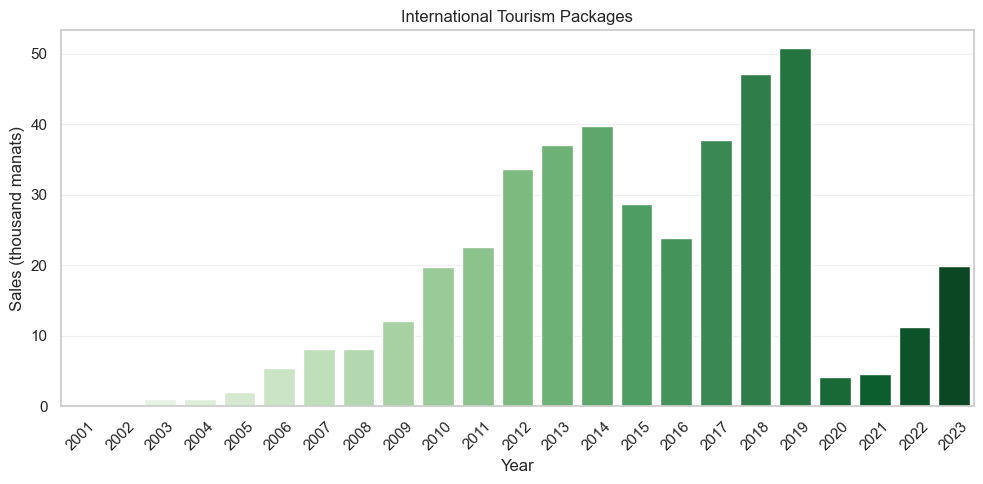

In [137]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure style
sns.set(style="whitegrid")

# --- Domestic Plot ---
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="Year",
    y="Domestic",
    palette="Blues"
)

plt.title("Domestic Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# --- International Plot ---
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_filtered_int,
    x="Year",
    y="International",
    palette="Greens"
)

plt.title("International Tourism Packages")
plt.xlabel("Year")
plt.ylabel("Sales (thousand manats)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [138]:
# Düzgün ilkinləşdirmə
lr_int = LinearRegression()
dt_int = DecisionTreeRegressor(random_state=42)
rf_int = RandomForestRegressor(random_state=42)

lr_dom = LinearRegression()
dt_dom = DecisionTreeRegressor(random_state=42)
rf_dom = RandomForestRegressor(random_state=42)
# Modelləri öyrət
lr_int.fit(x_train_int, y_train_int)
dt_int.fit(x_train_int, y_train_int)
rf_int.fit(x_train_int, y_train_int)
lr_dom.fit(x_train_dom, y_train_dom)
dt_dom.fit(x_train_dom, y_train_dom)
rf_dom.fit(x_train_dom, y_train_dom)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [139]:
lr_pred_int = lr_int.predict(x_test_int)
dt_pred_int = dt_int.predict(x_test_int)
rf_pred_int = rf_int.predict(x_test_int)

lr_pred_dom = lr_dom.predict(x_test_dom)
dt_pred_dom = dt_dom.predict(x_test_dom)
rf_pred_dom = rf_dom.predict(x_test_dom)

In [140]:
results_int = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_int, lr_pred_int)),
        np.sqrt(mean_squared_error(y_test_int, dt_pred_int)),
        np.sqrt(mean_squared_error(y_test_int, rf_pred_int))
    ],
    "MAE": [
        mean_absolute_error(y_test_int, lr_pred_int),
        mean_absolute_error(y_test_int, dt_pred_int),
        mean_absolute_error(y_test_int, rf_pred_int)
    ]
})

print("International Results:")
print(results_int)

International Results:
               Model       RMSE        MAE
0  Linear Regression  26.549188  19.977265
1      Decision Tree  11.741293  10.909100
2      Random Forest   6.521700   5.867235


## Modelin qiymətləndirilməsi
Modellərin ən dəqiq proqnoz yanaşmasını müəyyən etmək üçün qiymətləndirilir.

In [141]:
results_dom = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree", "Random Forest"],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test_dom, lr_pred_dom)),
        np.sqrt(mean_squared_error(y_test_dom, dt_pred_dom)),
        np.sqrt(mean_squared_error(y_test_dom, rf_pred_dom))
    ]
})

print("Domestic Results:")
print(results_dom)

Domestic Results:
               Model      RMSE
0  Linear Regression  4.528174
1      Decision Tree  1.475032
2      Random Forest  1.364387


## Model performansının vizuallaşdırılması
Model performansı proqnoz dəqiqliyini müqayisə etmək üçün vizuallaşdırılır.

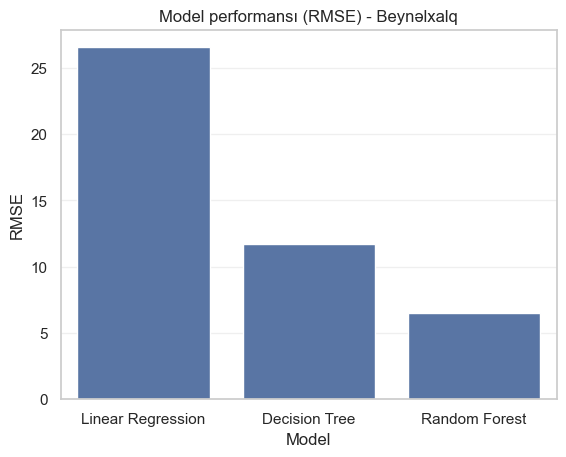

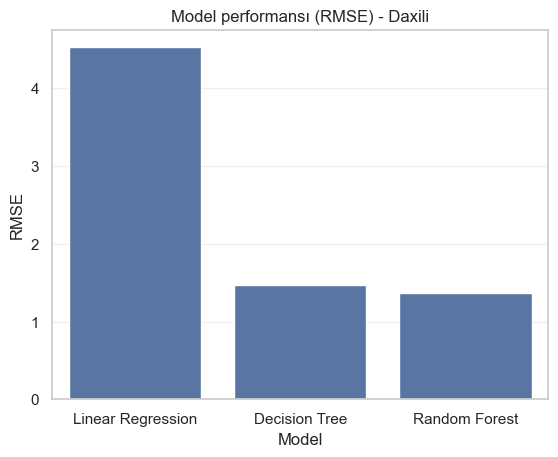

In [153]:
sns.barplot(data=results_int, x="Model", y="RMSE")

plt.title("Model performansı (RMSE) - Beynəlxalq")
plt.ylabel("RMSE")
plt.grid(axis='y', alpha=0.3)

plt.show()
sns.barplot(data=results_dom, x="Model", y="RMSE")

plt.title("Model performansı (RMSE) - Daxili")
plt.ylabel("RMSE")
plt.grid(axis='y', alpha=0.3)

plt.show()

The evaluation shows that Random Forest and Decision Tree models perform better than Linear Regression, especially for International sales, where Linear Regression has the highest error (RMSE). For Domestic sales, all models perform well, but Decision Tree gives the lowest error.

Even though Linear Regression is not the most accurate, it is still used in the final forecast because it captures the overall long-term trend clearly and smoothly, which is important for time-series forecasting stability.

## Gələcək proqnozlar

In [143]:
future = pd.DataFrame({"Year": range(2025, 2030)})

future["Covid"] = 0
future["Year_centered"] = future["Year"] - year_mean

x_future = future[features]

### Gələcək turizm proqnozları (2025–2029)
Seçilmiş model gələcək daxili və beynəlxalq turizm paket satışlarını təxmin etmək üçün istifadə olunur.

In [144]:
# --- Fərdi model proqnozları (SAĞLA)
future["Domestic_LR"] = lr_dom.predict(x_future)
future["Domestic_DT"] = dt_dom.predict(x_future)
future["Domestic_RF"] = rf_dom.predict(x_future)

future["International_LR"] = lr_int.predict(x_future)
future["International_DT"] = dt_int.predict(x_future)
future["International_RF"] = rf_int.predict(x_future)

In [145]:

future["Domestic_Forecast"] = (
    0.8 * future["Domestic_DT"] +
    0.2 * future["Domestic_LR"]
)

# Beynəlxalq → DT + LR
future["International_Forecast"] = (
    0.7 * future["International_DT"] +
    0.3 * future["International_LR"]
)

Son proqnozlar modellərin çəkili ortalamasından yaradılır:

* Daxili: 80% Qərar Ağacı + 20% Xətti Reqressiya
* Beynəlxalq: 70% Qərar Ağacı + 30% Xətti Reqressiya

Bu qarışım sabitliyi artırır və tək modeldən istifadə edərək həddən artıq uyğunlaşma riskini azaldır.

In [146]:
pred_df = future[[
    "Year",
    "Domestic_Forecast",
    "International_Forecast"
]]

print(pred_df)

   Year  Domestic_Forecast  International_Forecast
0  2025           2.053962               22.179285
1  2026           2.134560               23.042248
2  2027           2.215159               23.905212
3  2028           2.295758               24.768175
4  2029           2.376356               25.631138


### Proqnozların vizuallaşdırılması
Tarixi və proqnozlaşdırılmış dəyərlər uzunmüddətli meylləri göstərmək üçün birlikdə göstərilir.

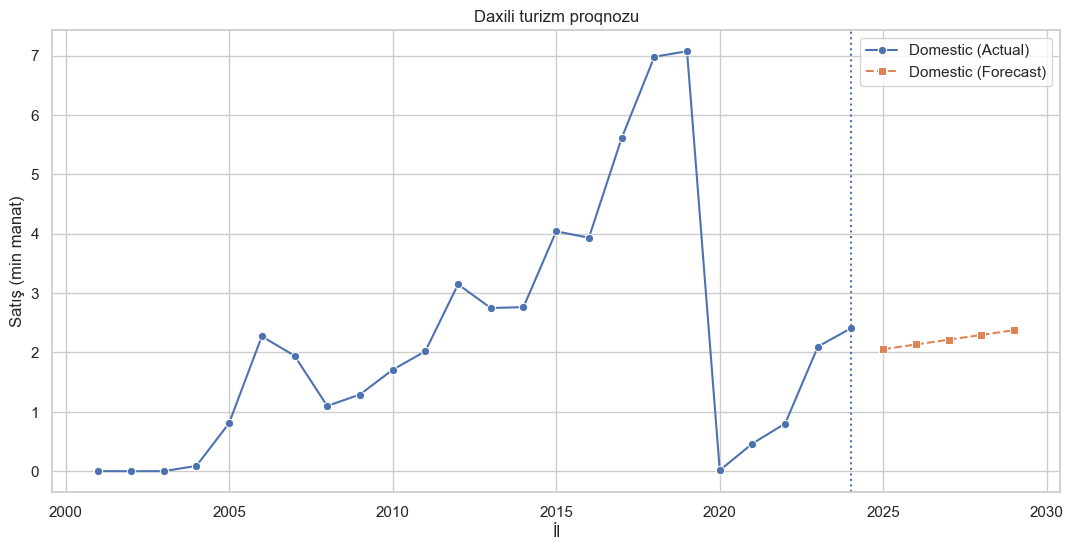

In [147]:
# Daxili
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="Domestic",
    marker="o",
    label="Domestic (Actual)"
)

sns.lineplot(
    data=pred_df,
    x="Year",
    y="Domestic_Forecast",
    marker="s",
    linestyle="--",
    label="Domestic (Forecast)"
)

plt.axvline(x=2024, linestyle=":", linewidth=1.5)

plt.title("Daxili turizm proqnozu")
plt.xlabel("İl")
plt.ylabel("Satış (min manat)")
plt.legend()
plt.show()

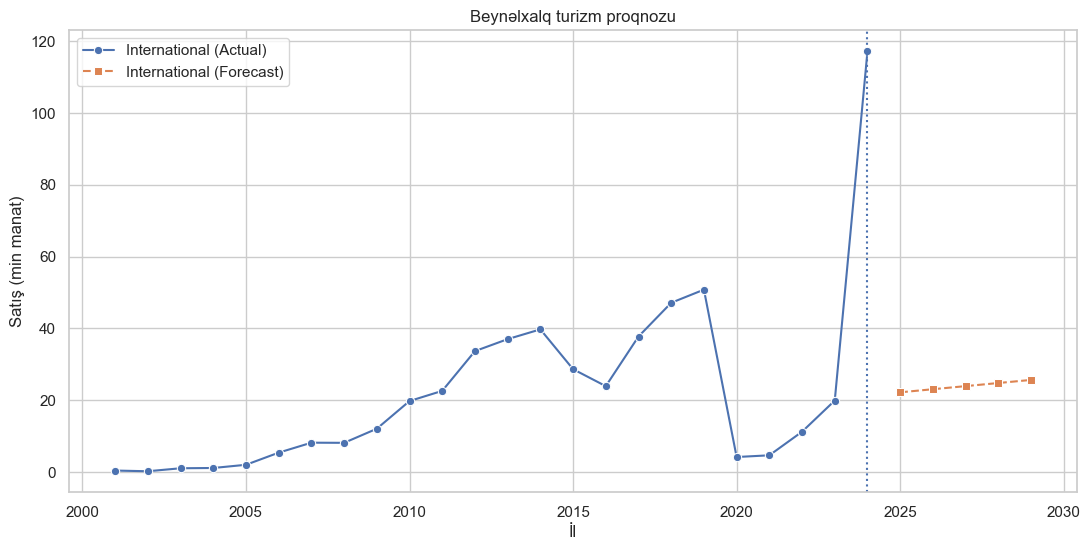

In [148]:
# International
plt.figure(figsize=(13, 6))

sns.lineplot(
    data=df,
    x="Year",
    y="International",
    marker="o",
    label="International (Actual)"
)

sns.lineplot(
    data=pred_df,
    x="Year",
    y="International_Forecast",
    marker="s",
    linestyle="--",
    label="International (Forecast)"
)

plt.axvline(x=2024, linestyle=":", linewidth=1.5)

plt.title("Beynəlxalq turizm proqnozu")
plt.xlabel("İl")
plt.ylabel("Satış (min manat)")
plt.legend()
plt.show()

## Suallara cavablar

1. **Daxili və beynəlxalq turizm paket satışları zamanla necə dəyişib?**
   * 2001–2004 illərində hər iki seqment üçün satışlar çox aşağı idi.
   * 2004–2019 illərində daxili satışlar tədricən böyüyüb və daha sabit artım göstərib.
   * Beynəlxalq satışlar 2003-cü ildən başlayaraq artıb, 2019-a qədər yüksəlişə davam edib.
   * 2020–2022 dövründə pandemiya səbəbindən hər iki seqmentdə azalma müşahidə olunub.
   * 2023–2024 illərdə daxili turizm güclü bərpa edib, beynəlxalq turizm isə daha yavaş olsa da yenidən artım mərhələsinə keçib.

2. **Hangi illər ən güclü artımı və ya azalmayı göstərib?**
   * Ən güclü azalma 2020 və 2021 illərində olub, xüsusilə beynəlxalq satışlarda.
   * Daxili satışlarda da 2020-ci ildə düşüş var, amma daha yumuşaq olub.
   * 2023–2024 illərdə ən güclü artım müşahidə olunur, xüsusən daxili turizm və 2024-cü ildə beynəlxalq satışlarda da artım.

3. **COVID-19 pandemiyası turizm paket satışlarına necə təsir edib?**
   * Pandemiya 2020–2022 illərində ciddi eniş səbəbi olub.
   * Beynəlxalq turizm ən çox təsirlənib, sərhəd qapanmaları və beynəlxalq səyahət məhdudiyyətləri səbəbindən.
   * Daxili turizm daha dayanıqlı qalıb, amma pandemiyanın ilk illərində o da azalıb.

4. **Pandemiyadan sonra hansı turizm növü daha tez bərpa olub?**
   * Daxili turizm daha tez bərpa olub.
   * 2023–2024 illərdə daxili satışlar daha sürətlə artıb və pandemiyadan sonra bərpa olunub.
   * Beynəlxalq turizm bərpa mərhələsinə keçib, lakin daha yavaş və 2024-cü ilə qədər tamamlanmamışdır.

5. **Növbəti beş il üçün satış meylləri necə gözlənilir?**
   * Model proqnozları göstərir ki, 2025–2029 illərdə həm daxili, həm beynəlxalq satışlarda artım davam edə bilər.
   * Daxili turizm proqnozları daha sabit və davamlı artım göstərir.
   * Beynəlxalq turizm üçün proqnozlar da müsbətdir, amma daha çox dəyişkənlik və dünya səyahət tendensiyalarından asılılıq var.
   * Ümumi trend: pandemiyadan sonra tədrici bərpa və yenidən artım.

> Qeyd: Bu cavablar mövcud tarix və proqnoz modelinə əsaslanır. Real nəticələr geopolitik, iqtisadi və sağlamlıq faktorlarından asılı olaraq dəyişə bilər.

## Nəticə
Pandemiya dövründə daxili turizm daha davamlı qaldı, beynəlxalq turizm isə daha güclü azalmalar yaşadı, lakin sonradan sabit şəkildə bərpa oldu.